 Lab 3 Data Analysis
### COMM 4259 <br> <i>Foundations of Machine Learning and AI</i>

© Jingjing Li- Ask for permission for using/quoting: jingjing.li@virginia.edu


## Lab Prep
* If you would like to see my screen on your computer, you can use web browser to login to Zoom, turn off the speaker and mute yourself.
    - Section 001, 11:00 a.m. – 12:15 p.m.: https://mcintire.zoom.us/j/95993311893?pwd=NmabjMgwCFyKkxzib3qMFahEDkkaSI.1
    - Section 002, 2:00 – 3:15 p.m.: https://mcintire.zoom.us/j/97629389481?pwd=GA37uPdbfC0154k4M3n17SGf6qaYCg.1

## Lab Rules
* Raise hands for questions
* Be prepared to share your screen for Q & A or exercises



# Python Libraries



<div style="background-color:#FFF4CE; color:#5C4200; border:1px solid #E8C86E; border-left:5px solid #D69E00; padding:15px; border-radius:4px;">
<b>Note: What is a library in Python?</b><br> 

Python has an abundance of additional libraries to extend the basic functionalities.

A library is a collection of functions for certain programming tasks.
</div>


## Common Libraries for Data Analysis

* **Numpy** is a library for data arrays ([Documentation](https://docs.scipy.org/doc/)).
* **Pandas** provides easy-to-use data structures and data analysis tools ([Documentation](https://pandas.pydata.org/)).
* **Matplotlib** is a library for data visualization ([Documentation](https://matplotlib.org/)).
* **Seaborn** is a higher-level interface to Matplotlib to simplify visualization codes ([Documentation](https://seaborn.pydata.org/)).

*__Important__: While this tutorial provides insight into the basics of these libraries,  I recommend digging into the online documentation for detailed usage.*


## Import libraries

The <mark>import</mark> is for accessing functions of certain libraries. 

The <mark>**as**</mark> keyword is used for creating an alias for libraries. 

<br>Usually, we use <mark>**pd**</mark> as an alias for <mark>**pandas**</mark> and <mark>**sns**</mark> as an alias for <mark>**seaborn**</mark>.


In [3]:
import pandas as pd
import seaborn as sns

In [5]:
print(pd.__version__)
print(sns.__version__)

2.2.2
0.13.2


In [ ]:
#pip install pandas --user
#pip install seaborn --user

After importing, functions of a library through a dot notation. For example, ```pd.read_csv()``` uses the **<mark>read_csv()</mark>** function inside the **<mark>pandas</mark>** library.

# Dataset

In the following, we will use the titanic survival data (titanic.csv) to illustrate how to use Python for data analysis. This dataset is used for the legendary Titanic ML competition – the best, first challenge for you to dive into ML competitions and familiarize yourself with how the Kaggle platform works.

The competition is simple: use machine learning to create a model that predicts which passengers survived the Titanic shipwreck.

You can learn more about this competition at the [Kaggle](https://www.kaggle.com/c/titanic/overview) website.

The description of the data is as follows:
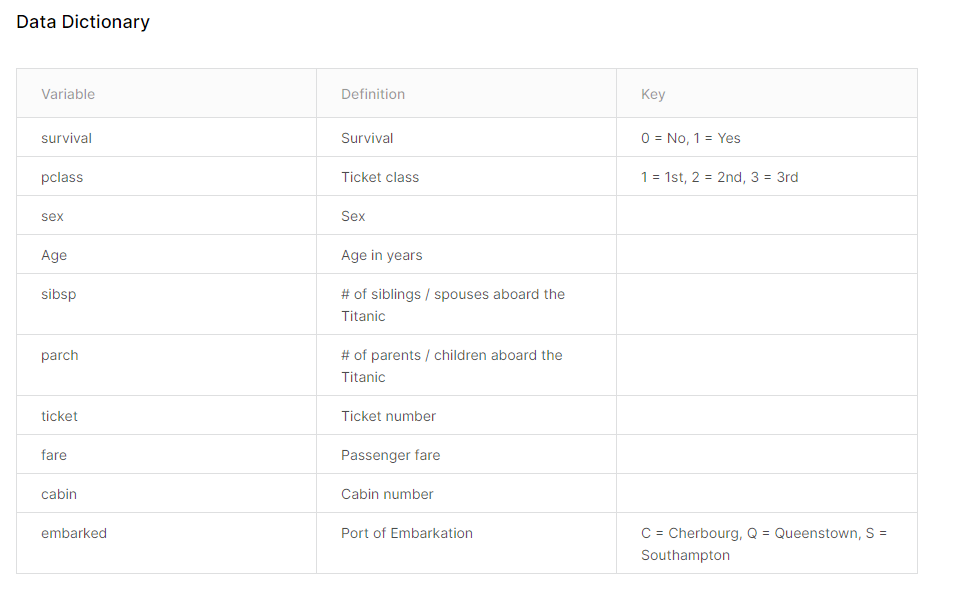

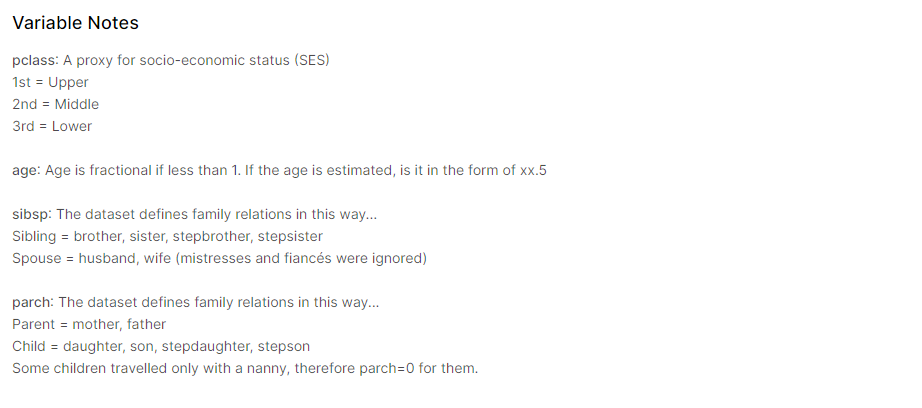

# Data Management
Data management is a crucial component to statistical analysis and data science work.  The following code will show how to import data via the pandas library, view your data, and transform your data.

The main data structure that Pandas works with is called a **Data Frame**.  This is a two-dimensional table of data in which the rows represent **instances** (e.g. Cartwheel Contest Participants), and the columns represent **attributes**.  Pandas also has a one-dimensional data structure called a **Series** that we will encounter when accesing a single column of a Data Frame.

Pandas has a variety of functions named '`read_xxx`' for reading data in different formats.  Right now we will focus on reading '`csv`' files, which stands for **comma-separated values**. However the other file formats include excel, json, and sql just to name a few.

There are many useful options in '`read_csv`'.  For example, you would use the option `sep='\t'` instead of the default `sep=','` if the fields of your data file are delimited by tabs instead of commas.  See [here](https://pandas.pydata.org/pandas-docs/stable/generated/pandas.read_csv.html) for the full documentation for '`read_csv`'.

<div style="background-color:#FFF4CE; color:#5C4200; border:1px solid #E8C86E; border-left:5px solid #D69E00; padding:15px; border-radius:4px;">
<b>Note: use Shift + Tab to show help info of functions</b><br> 

Once you typed the pd.read_csv() function, press Shift + Tab and click "+" in the dropdown menu. You will see detailed documentation and usage examples for this function.
</div>

## Read the data

In [15]:
import pandas as pd
# Store the url string that hosts our .csv file
url = "titanic.csv"

# Read the .csv file and store it as a pandas Data Frame
df = pd.read_csv(url)

# Output object type
type(df)

pandas.core.frame.DataFrame

## Show basic info

### Get the shape

In [18]:
df.shape # there are 891 rows and 12 columns in this dataset

(891, 12)

### Get the info

In [20]:
df.info() # there are 891 rows and 12 columns in this dataset

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


### Get the column names

In [22]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

Why do some pandas commands end with parentheses (and others don't)? Watch this [video](https://www.youtube.com/watch?v=hSrDViyKWVk).

### Rename columns

In [25]:
df.rename(columns = {'Ticket': 'TicketNumber'}, inplace = True) 
# inplace = True will change the dataframe's value; by default it is False
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,TicketNumber,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## View the data
### Get the top rows

In [27]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,TicketNumber,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


The head() function simply shows the first 5 rows of our Data Frame.  If we wanted to show the entire Data Frame we would simply write the following:

In [29]:
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,TicketNumber,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


If you want to show certain number of rows, just put the number inside the head() function

In [31]:
df.head(3) # show top 3 rows

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,TicketNumber,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S


### Show last 5 rows
Similarly, in order to show last rows, you can use the tail function. By default, it will show the last five rows in the dataset.

In [33]:
df.tail()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,TicketNumber,Fare,Cabin,Embarked
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.00,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.00,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.45,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.00,C148,C
890,891,0,3,"Dooley, Mr. Patrick",male,32.0,0,0,370376,7.75,NaN,Q


### Show columns
There are two ways to refer to a column in the dataframe
- dot notation: df.Name
- bracket notation: df["Name"]
  <br>Bracket notions works when column names contain empty spaces or use multiple columns.
  df["First Name"]
  df[["Name", "Pclass"]]

In [35]:
df.Name

0                                Braund, Mr. Owen Harris
1      Cumings, Mrs. John Bradley (Florence Briggs Th...
2                                 Heikkinen, Miss. Laina
3           Futrelle, Mrs. Jacques Heath (Lily May Peel)
4                               Allen, Mr. William Henry
                             ...                        
886                                Montvila, Rev. Juozas
887                         Graham, Miss. Margaret Edith
888             Johnston, Miss. Catherine Helen "Carrie"
889                                Behr, Mr. Karl Howell
890                                  Dooley, Mr. Patrick
Name: Name, Length: 891, dtype: object

In [36]:
df["Name"]

0                                Braund, Mr. Owen Harris
1      Cumings, Mrs. John Bradley (Florence Briggs Th...
2                                 Heikkinen, Miss. Laina
3           Futrelle, Mrs. Jacques Heath (Lily May Peel)
4                               Allen, Mr. William Henry
                             ...                        
886                                Montvila, Rev. Juozas
887                         Graham, Miss. Margaret Edith
888             Johnston, Miss. Catherine Helen "Carrie"
889                                Behr, Mr. Karl Howell
890                                  Dooley, Mr. Patrick
Name: Name, Length: 891, dtype: object

In [37]:
df[["Name", "Pclass"]]

,Name,Pclass
0,"Braund, Mr. Owen Harris",3
1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1
2,"Heikkinen, Miss. Laina",3
3,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1
4,"Allen, Mr. William Henry",3
...,...,...
886,"Montvila, Rev. Juozas",2
887,"Graham, Miss. Margaret Edith",1
888,"Johnston, Miss. Catherine Helen ""Carrie""",3
889,"Behr, Mr. Karl Howell",1


## Exercise 1: Read a dataframe

<div style="background-color:#DFF5DC; color:#14532D; border:1px solid #A5D6A7; border-left:5px solid #2E7D32; padding:15px; margin-bottom:20px; border-radius:4px;">
Complete Lab 3 Exercise Step 1-6.
Create a dataframe called fortune and store the data in the fortune500.csv file.
</div>

## Slice the data

Lets say we would like to splice our data frame and select only specific portions of our data.  There are at least two different ways of doing so.

1. .loc[]
2. .iloc[]

We will cover the .loc[] and .iloc[] splicing functions.


### .loc[] Select by label
.loc[] takes two single/list/range operator separated by ','. The first one refers to the row and the second one represents columns.


In [41]:
# return the name of the passenger in the first row
df.loc[0, "Name"] # 0 indicates first row, and Name is the column for passenger name

'Braund, Mr. Owen Harris'

In [42]:
# return all the names of the passenger
df.loc[:, "Name"] # : indicates all rows

0                                Braund, Mr. Owen Harris
1      Cumings, Mrs. John Bradley (Florence Briggs Th...
2                                 Heikkinen, Miss. Laina
3           Futrelle, Mrs. Jacques Heath (Lily May Peel)
4                               Allen, Mr. William Henry
                             ...                        
886                                Montvila, Rev. Juozas
887                         Graham, Miss. Margaret Edith
888             Johnston, Miss. Catherine Helen "Carrie"
889                                Behr, Mr. Karl Howell
890                                  Dooley, Mr. Patrick
Name: Name, Length: 891, dtype: object

The .loc[] function requires to arguments, the indices of the rows and the column names you wish to observe.

In the above case **\:** specifies all rows, and our column is **Name**. df.loc[**\:**,**"Name"**]

Now, let's say we only want to return the first 10 observations:

In [45]:
df.loc[:9, "Name"]

0                              Braund, Mr. Owen Harris
1    Cumings, Mrs. John Bradley (Florence Briggs Th...
2                               Heikkinen, Miss. Laina
3         Futrelle, Mrs. Jacques Heath (Lily May Peel)
4                             Allen, Mr. William Henry
5                                     Moran, Mr. James
6                              McCarthy, Mr. Timothy J
7                       Palsson, Master. Gosta Leonard
8    Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)
9                  Nasser, Mrs. Nicholas (Adele Achem)
Name: Name, dtype: object

In [46]:
# Select all rows for multiple columns, ["Name", "Sex", "Age"]
df.loc[:,["Name", "Sex", "Age"]]

,Name,Sex,Age
0,"Braund, Mr. Owen Harris",male,22.0
1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0
2,"Heikkinen, Miss. Laina",female,26.0
3,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0
4,"Allen, Mr. William Henry",male,35.0
...,...,...,...
886,"Montvila, Rev. Juozas",male,27.0
887,"Graham, Miss. Margaret Edith",female,19.0
888,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN
889,"Behr, Mr. Karl Howell",male,26.0


In [47]:
# Select range of rows for all columns
df.loc[10:15]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,TicketNumber,Fare,Cabin,Embarked
10,11,1,3,"Sandstrom, Miss. Marguerite Rut",female,4.0,1,1,PP 9549,16.7000,G6,S
11,12,1,1,"Bonnell, Miss. Elizabeth",female,58.0,0,0,113783,26.5500,C103,S
12,13,0,3,"Saundercock, Mr. William Henry",male,20.0,0,0,A/5. 2151,8.0500,NaN,S
13,14,0,3,"Andersson, Mr. Anders Johan",male,39.0,1,5,347082,31.2750,NaN,S
14,15,0,3,"Vestrom, Miss. Hulda Amanda Adolfina",female,14.0,0,0,350406,7.8542,NaN,S
15,16,1,2,"Hewlett, Mrs. (Mary D Kingcome)",female,55.0,0,0,248706,16.0000,NaN,S


### .iloc[] Select by position
.iloc[] is integer based slicing, whereas .loc[] used labels/column names. Here are some examples:

In [49]:
# Select the first four columns
df.iloc[:, :4]

,PassengerId,Survived,Pclass,Name
0,1,0,3,"Braund, Mr. Owen Harris"
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th..."
2,3,1,3,"Heikkinen, Miss. Laina"
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)"
4,5,0,3,"Allen, Mr. William Henry"
...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas"
887,888,1,1,"Graham, Miss. Margaret Edith"
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie"""
889,890,1,1,"Behr, Mr. Karl Howell"


In [50]:
# Select certain rows and columns
df.iloc[0:5, 2:4]

,Pclass,Name
0,3,"Braund, Mr. Owen Harris"
1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th..."
2,3,"Heikkinen, Miss. Laina"
3,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)"
4,3,"Allen, Mr. William Henry"


**Do not mix loc with iloc**
```python
# Running this will yield an error
df.iloc[1:5, ["Name", "Sex"]]
```

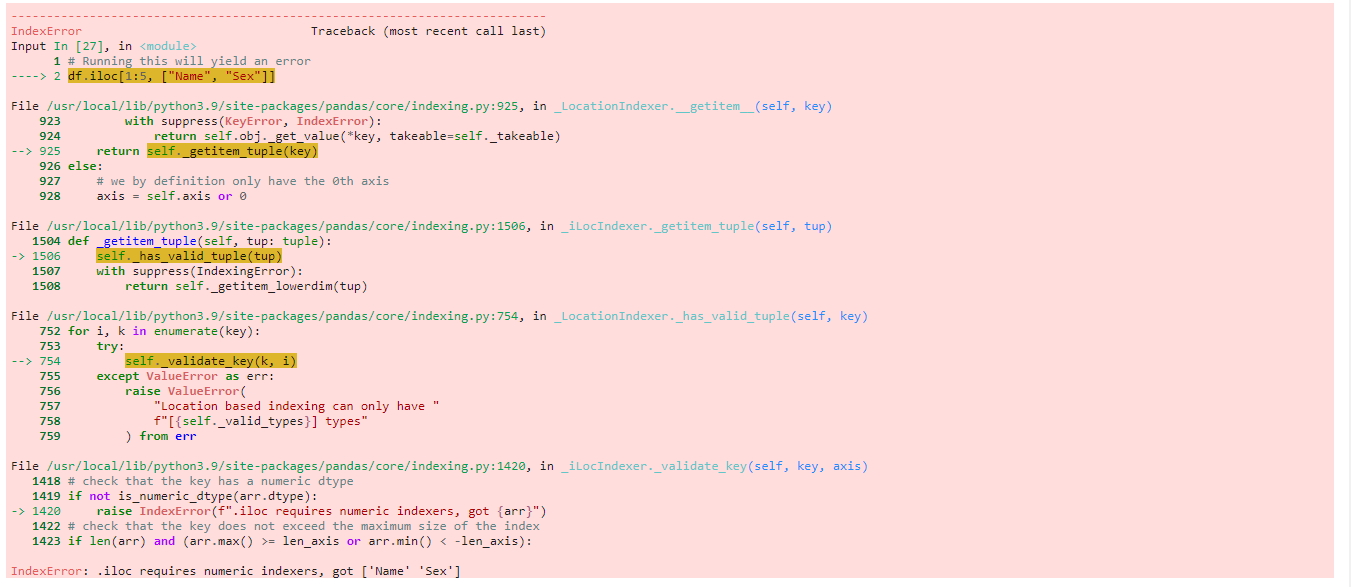

### Select data based on conditions

**Remember to use dot or bracket notation when referring certain columns**

In [53]:
# Get all the data with age > 30
df.loc[df.Age > 30]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,TicketNumber,Fare,Cabin,Embarked
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
11,12,1,1,"Bonnell, Miss. Elizabeth",female,58.0,0,0,113783,26.5500,C103,S
...,...,...,...,...,...,...,...,...,...,...,...,...
873,874,0,3,"Vander Cruyssen, Mr. Victor",male,47.0,0,0,345765,9.0000,NaN,S
879,880,1,1,"Potter, Mrs. Thomas Jr (Lily Alexenia Wilson)",female,56.0,0,1,11767,83.1583,C50,C
881,882,0,3,"Markun, Mr. Johann",male,33.0,0,0,349257,7.8958,NaN,S
885,886,0,3,"Rice, Mrs. William (Margaret Norton)",female,39.0,0,5,382652,29.1250,NaN,Q


In [54]:
# If we want all the columns, we can simplify the code as follows
df[df.Age > 30]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,TicketNumber,Fare,Cabin,Embarked
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
11,12,1,1,"Bonnell, Miss. Elizabeth",female,58.0,0,0,113783,26.5500,C103,S
...,...,...,...,...,...,...,...,...,...,...,...,...
873,874,0,3,"Vander Cruyssen, Mr. Victor",male,47.0,0,0,345765,9.0000,NaN,S
879,880,1,1,"Potter, Mrs. Thomas Jr (Lily Alexenia Wilson)",female,56.0,0,1,11767,83.1583,C50,C
881,882,0,3,"Markun, Mr. Johann",male,33.0,0,0,349257,7.8958,NaN,S
885,886,0,3,"Rice, Mrs. William (Margaret Norton)",female,39.0,0,5,382652,29.1250,NaN,Q


In [55]:
# If we want certain columns, we'd better use .loc
df.loc[df.Age > 30, "Name"]

1      Cumings, Mrs. John Bradley (Florence Briggs Th...
3           Futrelle, Mrs. Jacques Heath (Lily May Peel)
4                               Allen, Mr. William Henry
6                                McCarthy, Mr. Timothy J
11                              Bonnell, Miss. Elizabeth
                             ...                        
873                          Vander Cruyssen, Mr. Victor
879        Potter, Mrs. Thomas Jr (Lily Alexenia Wilson)
881                                   Markun, Mr. Johann
885                 Rice, Mrs. William (Margaret Norton)
890                                  Dooley, Mr. Patrick
Name: Name, Length: 305, dtype: object

In [56]:
# Multiple conditions
df.loc[(df.Age > 30) & (df.Age < 50), ["Age","Name"]]

,Age,Name
1,38.0,"Cumings, Mrs. John Bradley (Florence Briggs Th..."
3,35.0,"Futrelle, Mrs. Jacques Heath (Lily May Peel)"
4,35.0,"Allen, Mr. William Henry"
13,39.0,"Andersson, Mr. Anders Johan"
18,31.0,"Vander Planke, Mrs. Julius (Emelia Maria Vande..."
...,...,...
872,33.0,"Carlsson, Mr. Frans Olof"
873,47.0,"Vander Cruyssen, Mr. Victor"
881,33.0,"Markun, Mr. Johann"
885,39.0,"Rice, Mrs. William (Margaret Norton)"


## Exercise 2: Slice a dataframe

<div style="background-color:#DFF5DC; color:#14532D; border:1px solid #A5D6A7; border-left:5px solid #2E7D32; padding:15px; margin-bottom:20px; border-radius:4px;">
Complete Lab 3 Exercise Step 7-12.
</div>

# Exploratory Data Analysis

## Obtain Summary Statistics

In order to get the summary statistics for each column, we need to first understand the types of each column.

### Get column types

In [62]:
df.dtypes

PassengerId       int64
Survived          int64
Pclass            int64
Name             object
Sex              object
Age             float64
SibSp             int64
Parch             int64
TicketNumber     object
Fare            float64
Cabin            object
Embarked         object
dtype: object

### Change column types
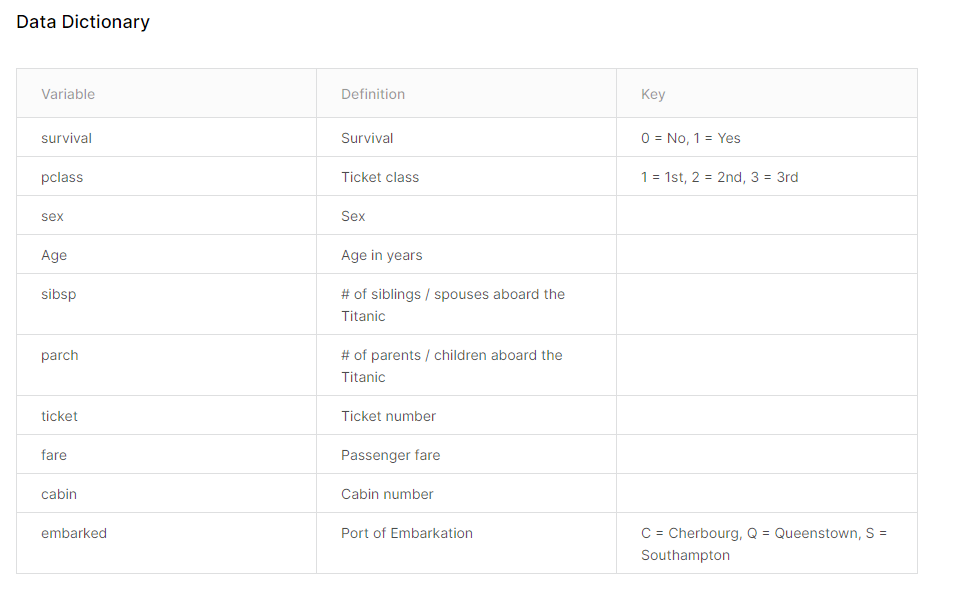

Based on data dictionary, PassengerId is an ID and should be treated as a string variable. Survived and Pclass are categorical variables and should be string variables as well.

**Remember to assign the type-changed dataframe back to the dataframe variable**

In [66]:
df = df.astype({"PassengerId": "str", "Pclass": "str"})
df.dtypes

PassengerId      object
Survived          int64
Pclass           object
Name             object
Sex              object
Age             float64
SibSp             int64
Parch             int64
TicketNumber     object
Fare            float64
Cabin            object
Embarked         object
dtype: object

### Get unique values for categorical data

In [68]:
df.Survived.unique()

array([0, 1])

### Get frequency table
The [value_counts](https://pandas.pydata.org/pandas-docs/stable/generated/pandas.Series.value_counts.html) method can be used to determine the number of times that each distinct value of a variable occurs in a data set.  In statistical terms, this is the "frequency distribution" of the variable.  Below we show the frequency distribution of the **Survived** variable.  The `value_counts` method produces a table with two columns.  The first column contains all distinct observed values for the variable.  The second column contains the number of times each of these values occurs.  Note that the table returned by `value_counts` is actually a Pandas data series, so can be further processed using any Pandas methods for working with data series.


In [70]:
df.Survived.value_counts()

Survived
0    549
1    342
Name: count, dtype: int64

For many purposes it is more relevant to consider the proportion of the sample with each of the possible category values, rather than the number of people in each category.  We can do this as follows:

In [72]:
x = df.Survived.value_counts()  # x is just a name to hold this value temporarily
x / x.sum()

Survived
0    0.616162
1    0.383838
Name: count, dtype: float64

### Describe the data

A quick way to get a set of numerical summaries for numerical variables is with the [describe](https://pandas.pydata.org/pandas-docs/stable/basics.html#summarizing-data-describe) function. 

In [74]:
# Describe all the numerical variables
df.describe()

,Survived,Age,SibSp,Parch,Fare
count,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,29.699118,0.523008,0.381594,32.204208
std,0.486592,14.526497,1.102743,0.806057,49.693429
min,0.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,80.000000,8.000000,6.000000,512.329200


In [75]:
# Describe one numerical variable
df.Age.describe()

count    714.000000
mean      29.699118
std       14.526497
min        0.420000
25%       20.125000
50%       28.000000
75%       38.000000
max       80.000000
Name: Age, dtype: float64

Notice that the **describe()** function removes missing values (the count of row is 714 rather than 891). 

It's also possible to calculate individual summary statistics from one column of a data set.  This can be done using Pandas methods, or with numpy functions:

In [78]:
x = df.Age # Extract all non-missing values of BMXWT into a variable called 'x'
print(x.mean()) # Pandas method
print(x.median()) # Pandas method
print(x.quantile(0.75)) # Pandas method for quantiles, equivalent to 75th percentile

29.69911764705882
28.0
38.0


### Aggregate dataframe

We can use the **groupby( )** to aggregate the data based on central tendency measures (e.g. mean, sum).

<div style="background-color:#FFF4CE; color:#5C4200; border:1px solid #E8C86E; border-left:5px solid #D69E00; padding:15px; border-radius:4px;">
You can watch this <a style="color:#0645AD; font-weight:600;" href="https://www.youtube.com/watch?v=qy0fDqoMJx8&list=PL5-da3qGB5ICCsgW1MxlZ0Hq8LL5U3u9y&index=14"> video</a> to learn more about the groupby() function.    
</div>

In [81]:
df.groupby(["Sex"]).mean(numeric_only=True)

,Survived,Age,SibSp,Parch,Fare
Sex,,,,,
female,0.742038,27.915709,0.694268,0.649682,44.479818
male,0.188908,30.726645,0.429809,0.235702,25.523893


In [82]:
df.groupby(["Sex", "Pclass"]).mean(numeric_only=True)

Survived        Age     SibSp     Parch        Fare
Sex    Pclass                                                     
female 1       0.968085  34.611765  0.553191  0.457447  106.125798
       2       0.921053  28.722973  0.486842  0.605263   21.970121
       3       0.500000  21.750000  0.895833  0.798611   16.118810
male   1       0.368852  41.281386  0.311475  0.278689   67.226127
       2       0.157407  30.740707  0.342593  0.222222   19.741782
       3       0.135447  26.507589  0.498559  0.224784   12.661633

In [83]:
df.groupby(["Sex", "Pclass"]).Survived.mean()

Sex     Pclass
female  1         0.968085
        2         0.921053
        3         0.500000
male    1         0.368852
        2         0.157407
        3         0.135447
Name: Survived, dtype: float64

##  Visualization
Quantitative variables can be effectively summarized graphically. We will use seaborn library.

<div style="background-color:#FFF4CE; color:#5C4200; border:1px solid #E8C86E; border-left:5px solid #D69E00; padding:15px; border-radius:4px;">
You can watch this <a style="color:#0645AD; font-weight:600;" href="https://www.youtube.com/watch?v=6GUZXDef2U0"> video</a> to have a 60-min tutorial about all seaborn plots.    
</div>

### Choose color palette. 
Seaborn allows you to choose a palette for visualization. For more palette selections, read [here](https://seaborn.pydata.org/tutorial/color_palettes.html)

In [87]:
# see color palette
sns.color_palette("pastel")

[(0.6313725490196078, 0.788235294117647, 0.9568627450980393),
 (1.0, 0.7058823529411765, 0.5098039215686274),
 (0.5529411764705883, 0.8980392156862745, 0.6313725490196078),
 (1.0, 0.6235294117647059, 0.6078431372549019),
 (0.8156862745098039, 0.7333333333333333, 1.0),
 (0.8705882352941177, 0.7333333333333333, 0.6078431372549019),
 (0.9803921568627451, 0.6901960784313725, 0.8941176470588236),
 (0.8117647058823529, 0.8117647058823529, 0.8117647058823529),
 (1.0, 0.996078431372549, 0.6392156862745098),
 (0.7254901960784313, 0.9490196078431372, 0.9411764705882353)]

In [88]:
# set color palette
sns.set_palette("pastel")

### Creating a Histogram

Histogram allows you inspect the spread and skewness of a variable.
Read more about **histplot** [here](https://seaborn.pydata.org/generated/seaborn.histplot.html).

As with many dataset, some data values are missing. For instance, the age variable has 891-714 = 177 missing values.
So we explicitly drop the missing cases using the [dropna](https://pandas.pydata.org/pandas-docs/stable/missing_data.html#dropping-axis-labels-with-missing-data-dropna) method before generating the graphs.

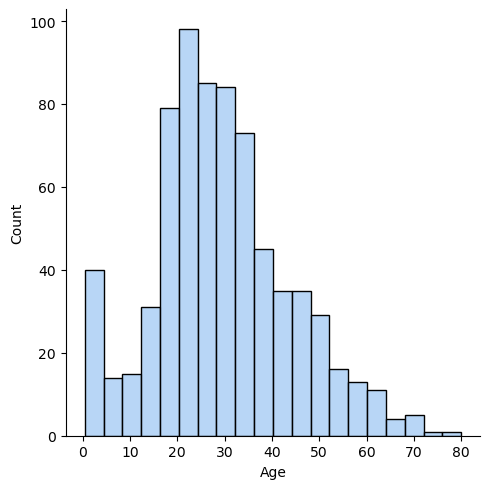

In [90]:
# import seaborn as sns
# Plot a histogram of the Age
sns.displot(df.Age.dropna())

Text(0.5, 1.0, 'Histogram of Passenger Age')

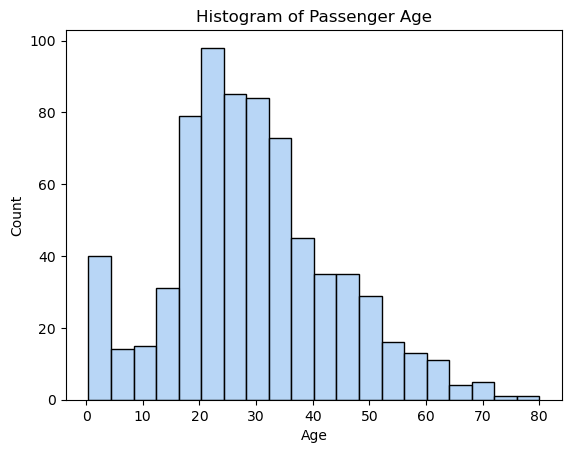

In [91]:
# Improve the graph by getting rid of the KDE and add title
# Kernel Density Estimation (KDE) is a way to estimate 
# the probability density function of a continuous random variable.
sns.histplot(df.Age.dropna(), kde = False).set_title("Histogram of Passenger Age")

Text(0.5, 1.0, 'Histogram of Both Age and Fare')

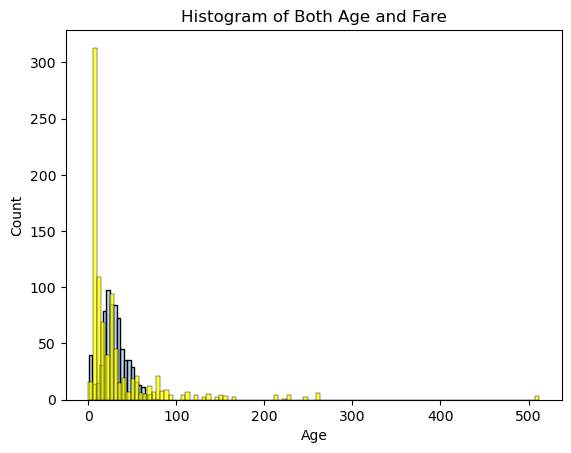

In [92]:
# Plot a histogram of both the Age and Fare
sns.histplot(df.Age.dropna(), kde = False)
sns.histplot(df.Fare.dropna(), kde = False, color = "yellow").set_title("Histogram of Both Age and Fare")

In [93]:
df1 = df.loc[df.Age > 30]

<Axes: xlabel='Age', ylabel='Count'>

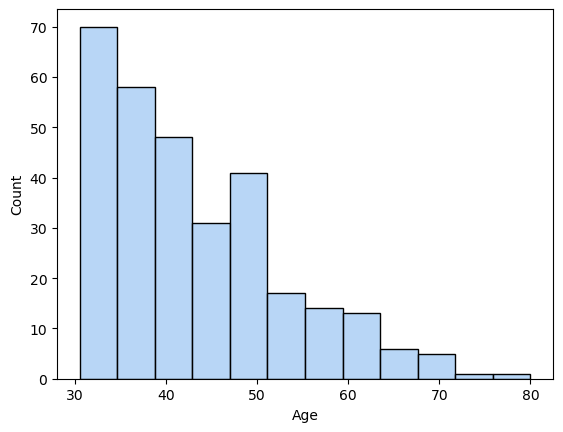

In [94]:
# Combine loc function with plot
sns.histplot(df1.Age.dropna(),kde = False)

<Axes: xlabel='Age', ylabel='Count'>

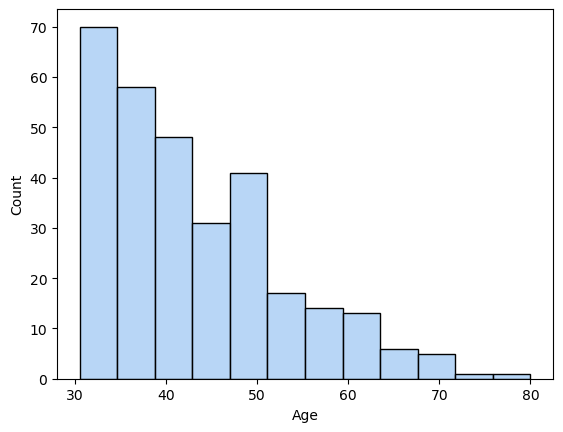

In [95]:
# Combine loc with plot--alternative ways
sns.histplot(df.loc[df.Age > 30, "Age"].dropna(), kde = False)

### Creating a Boxplot

Boxplots do not show the shape of the distribution, but they can give us a better idea about the center and spread of the distribution as well as any potential outliers that may exist. Boxplots and Histograms often complement each other and help an analyst get more information about the data. Understand the concept for boxplot [here](https://www.youtube.com/watch?v=U0NZu6f5TMI) and [here](https://towardsdatascience.com/understanding-boxplots-5e2df7bcbd51). For Python documentation of boxplot, read [here](https://seaborn.pydata.org/generated/seaborn.boxplot.html).

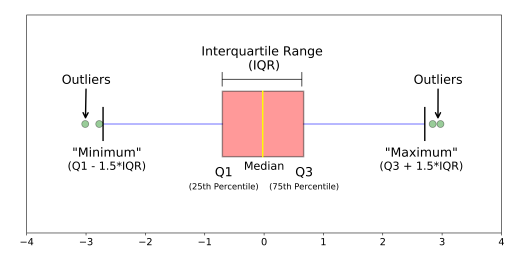

Text(0.5, 1.0, 'Box plot of the Age')

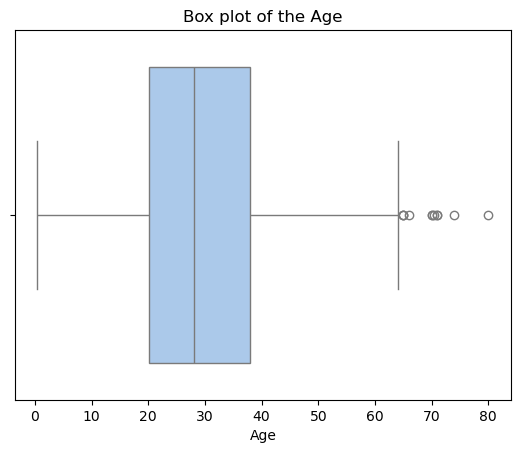

In [97]:
# Create a boxplot of the age
sns.boxplot(x = df.Age.dropna()).set_title("Box plot of the Age")

### Creating Histograms and Boxplots Plotted by Groups

While looking at a single variable is interesting, it is often useful to see how a variable changes in response to another. Using graphs, we can see if there is a difference between the age of survived vs. non-survived.

<Axes: xlabel='Survived', ylabel='Age'>

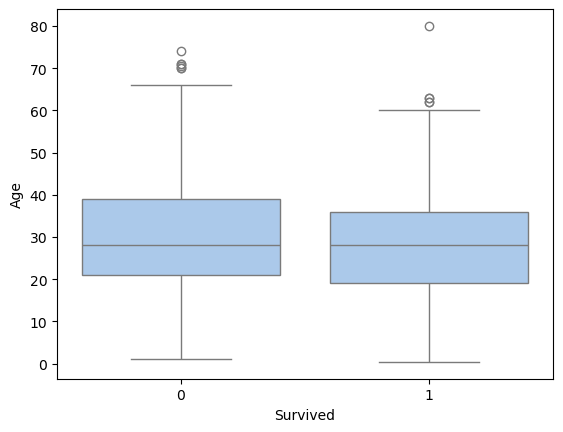

In [99]:
# Create a boxplot and histogram of the Age grouped by Survived Status
sns.boxplot(x = "Survived", y = "Age", data = df)

<Axes: xlabel='Survived', ylabel='Age'>

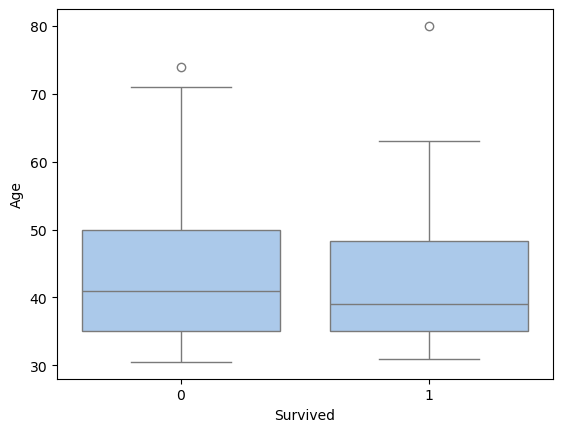

In [100]:
# Combine loc with plot
df1 = df.loc[df.Age > 30]
sns.boxplot(x = "Survived", y = "Age", data = df1)

### Using Facetgrid

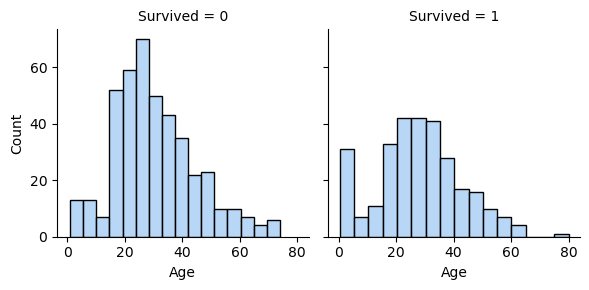

In [102]:
# Draw two histograms of age separated by survived.
g = sns.FacetGrid(df, col = "Survived")
g = g.map(sns.histplot,  "Age")

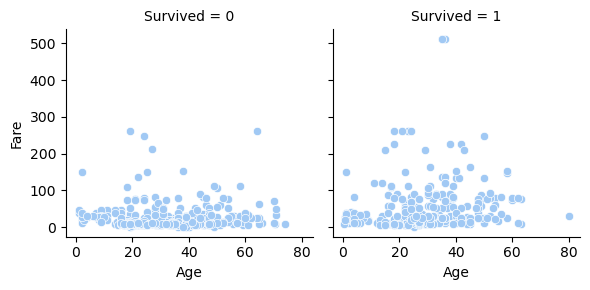

In [103]:
# Draw two scatterplot of age and fare separated by sex.
g = sns.FacetGrid(df, col = "Survived")
g = g.map(sns.scatterplot,  "Age", "Fare")

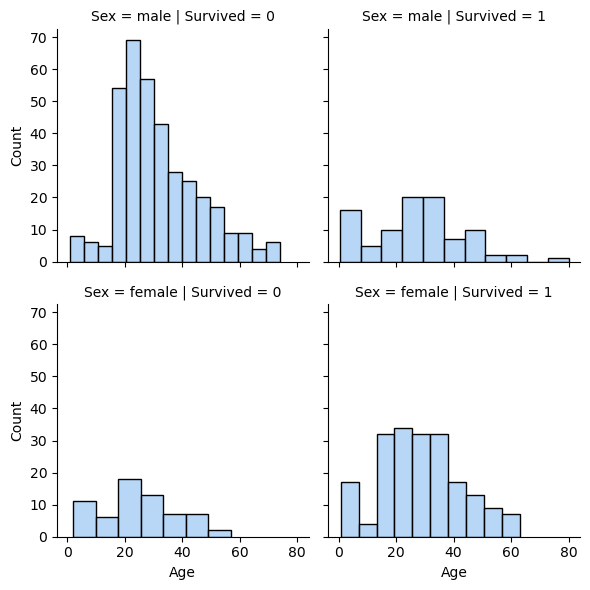

In [104]:
# combine Rows and Columns in a FacetGrid
g = sns.FacetGrid(df, col = "Survived", row = "Sex")
g = g.map(sns.histplot, "Age")

### Creating a Scatter Plot

Scatter plot can show the relationships of multiple variables

<Axes: xlabel='Age', ylabel='Fare'>

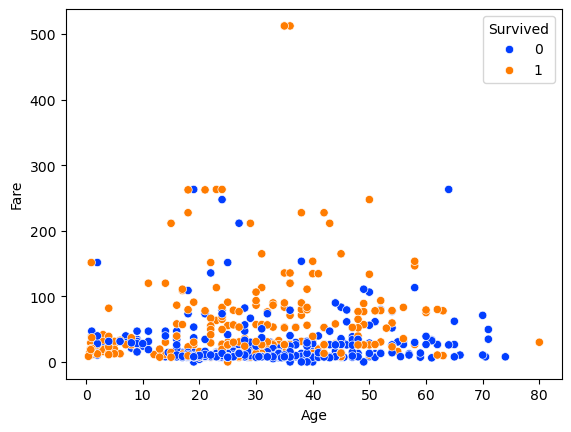

In [106]:
sns.scatterplot(x = "Age", y = "Fare",
                     hue = "Survived",
                     palette="bright", # color palette from seaborn
                     data = df)

### More Plot Types
There are many other types plots avaialbe in Seaborn. Check out the [Documentation](https://seaborn.pydata.org/) to learn more.

## Exercise 3: Exploratory Data Analysis

<div style="background-color:#DFF5DC; color:#14532D; border:1px solid #A5D6A7; border-left:5px solid #2E7D32; padding:15px; margin-bottom:20px; border-radius:4px;">
Complete Lab 3 Exercise Step 13-18.
</div>